/tmp/ipykernel_75652/2780136489.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_75652/2780136489.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


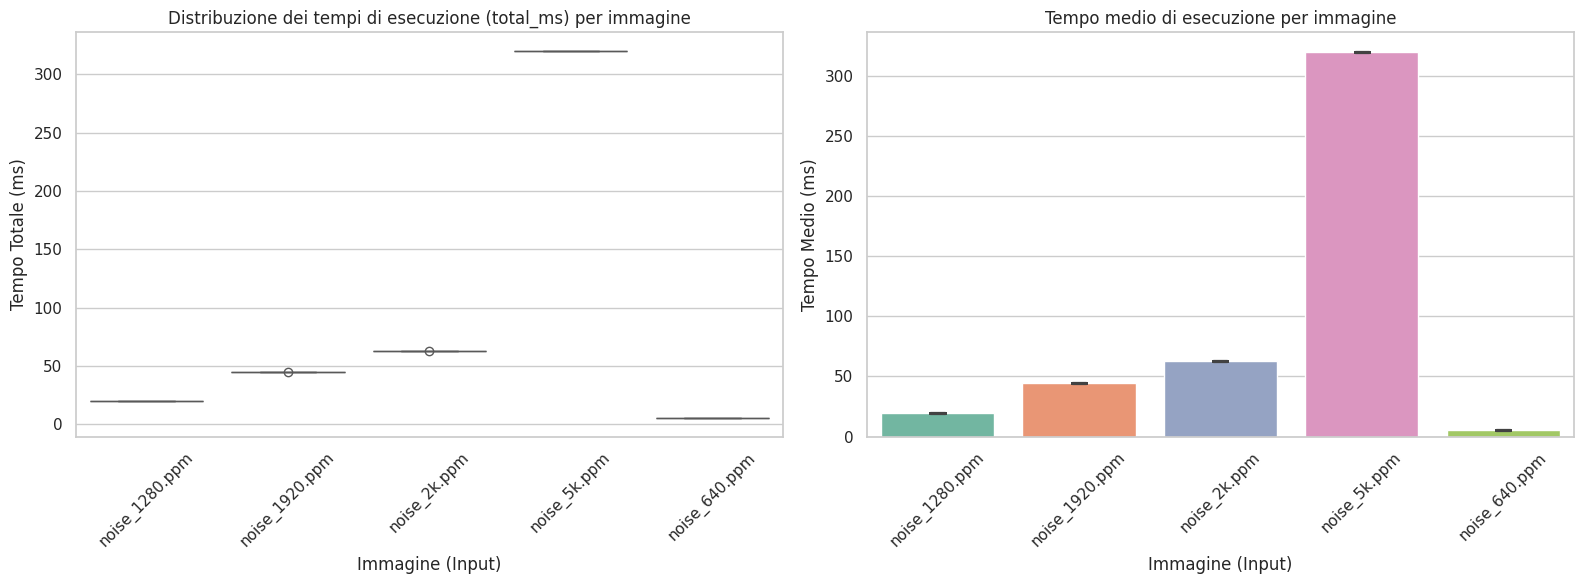

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carica i dati dal file CSV
# Sostituisci 'denoise_1.csv' con il percorso corretto se il file è in un'altra cartella
df = pd.read_csv('denoise_1.csv')

# (Opzionale) Pulisci i dati tenendo solo le esecuzioni con status 'ok'
df = df[df['status'] == 'ok']

# Imposta lo stile di Seaborn per grafici più eleganti
sns.set_theme(style="whitegrid")

# Crea una figura con due sotto-grafici (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFICO 1: Boxplot dei tempi totali per ogni immagine ---
# Mostra la distribuzione, la mediana e gli eventuali valori anomali dei tempi (total_ms)
sns.boxplot(
    data=df, 
    x='image', 
    y='total_ms', 
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Distribuzione dei tempi di esecuzione (total_ms) per immagine')
axes[0].set_xlabel('Immagine (Input)')
axes[0].set_ylabel('Tempo Totale (ms)')
axes[0].tick_params(axis='x', rotation=45) # Ruota le etichette dell'asse x per leggerle meglio

# --- GRAFICO 2: Grafico a barre del tempo medio di esecuzione ---
# Calcola la media e mostra la deviazione standard come barra di errore
sns.barplot(
    data=df, 
    x='image', 
    y='total_ms', 
    ax=axes[1],
    palette='Set2',
    capsize=0.1
)
axes[1].set_title('Tempo medio di esecuzione per immagine')
axes[1].set_xlabel('Immagine (Input)')
axes[1].set_ylabel('Tempo Medio (ms)')
axes[1].tick_params(axis='x', rotation=45)

# Aggiusta il layout per evitare che le scritte si sovrappongano
plt.tight_layout()

# Mostra il grafico
plt.show()

C:\Users\marra\AppData\Local\Temp\ipykernel_21244\2748094137.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


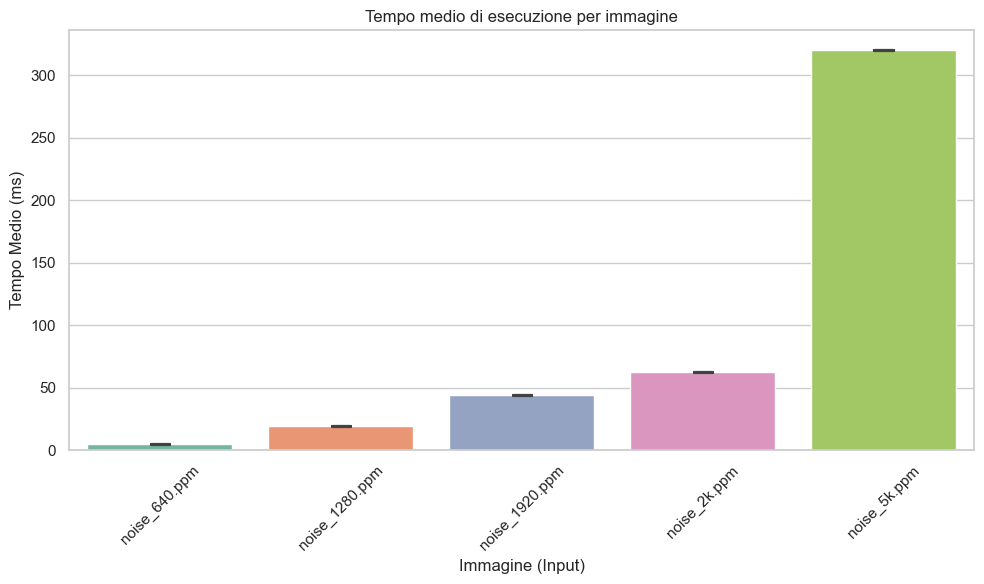

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carica i dati dal file CSV
df = pd.read_csv('denoise_1.csv')

# Filtra solo le esecuzioni con status 'ok'
df = df[df['status'] == 'ok']

# 2. Definisci l'ordine personalizzato per l'asse X
# Recuperiamo tutti i nomi unici delle immagini
immagini = df['image'].unique().tolist()

# Cerchiamo l'immagine che contiene '640' e la spostiamo all'inizio della lista
nome_640 = next((img for img in immagini if '640' in str(img)), None)
if nome_640 and nome_640 in immagini:
    immagini.remove(nome_640)
    immagini.insert(0, nome_640) # Inserisce in prima posizione (indice 0)

# Imposta lo stile
sns.set_theme(style="whitegrid")

# Crea una singola figura
plt.figure(figsize=(10, 6))

# --- GRAFICO: a barre del tempo medio di esecuzione ---
sns.barplot(
    data=df, 
    x='image', 
    y='total_ms', 
    order=immagini,      # <--- Questo parametro forza l'ordine che abbiamo deciso sopra
    palette='Set2',
    capsize=0.1
)

# Imposta titoli ed etichette
plt.title('Tempo medio di esecuzione per immagine')
plt.xlabel('Immagine (Input)')
plt.ylabel('Tempo Medio (ms)')
plt.xticks(rotation=45) # Ruota il testo per renderlo leggibile

# Aggiusta i margini
plt.tight_layout()

# Mostra il grafico
plt.show()

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definisci l'array dei file CSV da elaborare e la cartella di destinazione
# Sostituisci questi nomi con i percorsi reali dei tuoi file
lista_csv = ['denoise_1.csv','denoise_1_1.csv', 'denoise_1_2.csv', 'denoise_1_3.csv','denoise_1_4.csv','denoise_2.csv', 'denoise_2_1.csv'] 

cartella_output = 'plots' # Nome della cartella in cui salvare le immagini

# 2. Crea la cartella di destinazione se non esiste già
if not os.path.exists(cartella_output):
    os.makedirs(cartella_output)
    print(f"Cartella '{cartella_output}' creata.")

# Imposta lo stile globale per i grafici
sns.set_theme(style="whitegrid")

# 3. Esegui un ciclo attraverso ogni file nell'array
for file_csv in lista_csv:
    try:
        # Carica i dati
        df = pd.read_csv(file_csv)
        
        # Filtra solo le esecuzioni con status 'ok' (se la colonna esiste)
        if 'status' in df.columns:
            df = df[df['status'] == 'ok']
        
        # Definisci l'ordine personalizzato per l'asse X
        immagini = df['image'].unique().tolist()
        
        # Cerca l'immagine che contiene '640' e spostala all'inizio
        nome_640 = next((img for img in immagini if '640' in str(img)), None)
        if nome_640 and nome_640 in immagini:
            immagini.remove(nome_640)
            immagini.insert(0, nome_640)
        
        # Crea una nuova figura per questo specifico CSV
        plt.figure(figsize=(10, 6))
        
        # Crea il grafico a barre
        sns.barplot(
            data=df, 
            x='image', 
            y='total_ms', 
            order=immagini,
            palette='Set2',
            capsize=0.1
        )
        
        # Ottieni solo il nome del file (senza il percorso) per usarlo nel titolo
        nome_base = os.path.basename(file_csv)
        
        # Imposta titoli ed etichette
        plt.title(f'Tempo medio di esecuzione - {nome_base}')
        plt.xlabel('Immagine (Input)')
        plt.ylabel('Tempo Medio (ms)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        # 4. Salva il grafico
        # Crea il nome per il file immagine (es. denoise_1.csv -> grafico_denoise_1.png)
        nome_immagine = f"grafico_{nome_base.replace('.csv', '.png')}"
        percorso_salvataggio = os.path.join(cartella_output, nome_immagine)
        
        # Salva l'immagine nella cartella (dpi=300 garantisce un'ottima risoluzione)
        plt.savefig(percorso_salvataggio, dpi=300)
        print(f"✅ Grafico salvato con successo: {percorso_salvataggio}")
        
        # 5. IMPORTANTE: Chiudi la figura per liberare la memoria 
        # e per evitare che il prossimo grafico si sovrapponga a questo!
        plt.close()
        
    except FileNotFoundError:
        print(f"❌ Errore: Il file '{file_csv}' non è stato trovato.")
    except Exception as e:
        print(f"❌ Si è verificato un errore processando '{file_csv}': {e}")

print("Elaborazione completata!")

Cartella 'plots' creata.


C:\Users\marra\AppData\Local\Temp\ipykernel_21244\461888463.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✅ Grafico salvato con successo: plots\grafico_denoise_1.png


C:\Users\marra\AppData\Local\Temp\ipykernel_21244\461888463.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✅ Grafico salvato con successo: plots\grafico_denoise_1_1.png


...

✅ Grafico salvato con successo: plots\grafico_denoise_1_4.png


C:\Users\marra\AppData\Local\Temp\ipykernel_21244\461888463.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✅ Grafico salvato con successo: plots\grafico_denoise_2.png


C:\Users\marra\AppData\Local\Temp\ipykernel_21244\461888463.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✅ Grafico salvato con successo: plots\grafico_denoise_2_1.png
Elaborazione completata!


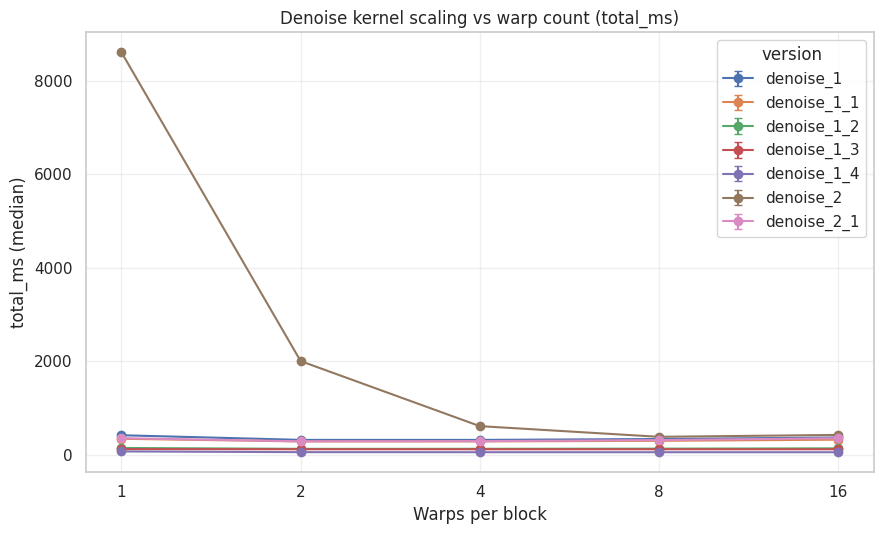

       base  warps    median        mean      std      min      max
  denoise_1      1  422.2440  422.249450 0.035116  422.189  422.330
  denoise_1      2  322.9730  322.975400 0.073160  322.810  323.141
  denoise_1      4  322.4815  322.476150 0.054747  322.367  322.645
  denoise_1      8  341.2705  341.283150 0.071849  341.144  341.470
  denoise_1     16  374.5760  374.585400 0.070939  374.450  374.842
denoise_1_1      1  346.4925  346.493300 0.031674  346.429  346.594
denoise_1_1      2  289.6605  289.658767 0.049080  289.572  289.759
denoise_1_1      4  289.6690  289.665467 0.050578  289.545  289.764
denoise_1_1      8  303.2545  303.265333 0.062351  303.147  303.403
denoise_1_1     16  327.5690  327.577933 0.044430  327.481  327.671
denoise_1_2      1  149.8960  149.892500 0.061613  149.786  150.051
denoise_1_2      2  131.4830  131.482133 0.058235  131.396  131.608
denoise_1_2      4  132.3795  132.370333 0.050606  132.290  132.468
denoise_1_2      8  135.9580  135.947567 0.05677

In [3]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---
METRIC = "total_ms"       # change to "slow_ms", "fast_ms", or "sort_ms" if you prefer
AGG    = "median"         # "median" is robust; "mean" also fine
PATTERN = "denoise_*_warps.csv"

# --- load ---
frames = []
for path in sorted(glob.glob(PATTERN)):
    df = pd.read_csv(path)
    df = df[df["status"] == "ok"]
    # split executable like "denoise_1_2_w4" -> base "denoise_1_2", warps 4
    m = df["executable"].str.extract(r"^(?P<base>.+?)_w(?P<warps>\d+)$")
    df["base"]  = m["base"]
    df["warps"] = m["warps"].astype(int)
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

# --- aggregate per (base, warps) ---
agg = (data.groupby(["base", "warps"])[METRIC]
            .agg(["median", "mean", "std", "min", "max"])
            .reset_index()
            .sort_values(["base", "warps"]))

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5.5))
for base, sub in agg.groupby("base"):
    ax.errorbar(sub["warps"], sub[AGG],
                yerr=sub["std"], marker="o", capsize=3, label=base)

ax.set_xlabel("Warps per block")
ax.set_ylabel(f"{METRIC} ({AGG})")
ax.set_title(f"Denoise kernel scaling vs warp count ({METRIC})")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(agg["warps"].unique()))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.grid(True, alpha=0.3)
ax.legend(title="version", loc="best")
fig.tight_layout()
plt.show()

# optional: print the table
print(agg.to_string(index=False))

In [ ]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---
METRIC = "total_ms"
AGG    = "median"
PATTERN = "denoise_*_warps.csv"
EXCLUDE = {"denoise_2"}   # bases to drop

# --- load ---
frames = []
for path in sorted(glob.glob(PATTERN)):
    df = pd.read_csv(path)
    df = df[df["status"] == "ok"]
    m = df["executable"].str.extract(r"^(?P<base>.+?)_w(?P<warps>\d+)$")
    df["base"]  = m["base"]
    df["warps"] = m["warps"].astype(int)
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

# --- aggregate per (base, warps) ---
agg = (data.groupby(["base", "warps"])[METRIC]
            .agg(["median", "mean", "std", "min", "max"])
            .reset_index()
            .sort_values(["base", "warps"]))

# --- drop excluded versions ---
agg = agg[~agg["base"].isin(EXCLUDE)]

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5.5))
for base, sub in agg.groupby("base"):
    ax.errorbar(sub["warps"], sub[AGG],
                yerr=sub["std"], marker="o", capsize=3, label=base)

ax.set_xlabel("Warps per block")
ax.set_ylabel(f"{METRIC} ({AGG})")
ax.set_title(f"Denoise kernel scaling vs warp count ({METRIC})")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(agg["warps"].unique()))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.grid(True, alpha=0.3)
ax.legend(title="version", loc="best")
fig.tight_layout()
plt.show()